In [1]:
!pip install pandas seaborn scikit-learn

import pandas as pd
import seaborn as sns
import sklearn

print("pandas:", pd.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)

pandas: 1.3.5
seaborn: 0.12.2
scikit-learn: 1.0.2


In [2]:
import numpy as np
import random
import tensorflow as tf

np.random.seed(101)
random.seed(101)
tf.random.set_seed(101)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import itertools

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [3]:
os.listdir(r'C:/Users/konyang/Desktop/archive')

['binary_sorted_images',
 'HAM10000_images_part_1',
 'HAM10000_images_part_2',
 'HAM10000_metadata.csv',
 'hmnist_28_28_L.csv',
 'hmnist_28_28_RGB.csv',
 'hmnist_8_8_L.csv',
 'hmnist_8_8_RGB.csv',
 'sorted_images']

### Create the directory structure

In these folders we will store the images that will later be fed to the Keras generators. 

In [4]:
import os
import shutil

base_dir = 'base_dir'
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)
os.mkdir(base_dir)

train_dir = os.path.join(base_dir, 'train_dir')
val_dir = os.path.join(base_dir, 'val_dir')
os.mkdir(train_dir)
os.mkdir(val_dir)

classes = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

for cls in classes:
    os.mkdir(os.path.join(train_dir, cls))

for cls in classes:
    os.mkdir(os.path.join(val_dir, cls))

### Create Train and Val Sets

In [5]:
df_data = pd.read_csv(r'C:/Users/konyang/Desktop/archive/HAM10000_metadata.csv')

df_data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


### Create a stratified val set

In [6]:
df = df_data.groupby('lesion_id').count()
df = df[df['image_id'] == 1]

df.reset_index(inplace=True)
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000001,1,1,1,1,1,1
1,HAM_0000003,1,1,1,1,1,1
2,HAM_0000004,1,1,1,1,1,1
3,HAM_0000007,1,1,1,1,1,1
4,HAM_0000008,1,1,1,1,1,1


In [7]:
def identify_duplicates(x):
    unique_list = list(df['lesion_id'])
    if x in unique_list:
        return 'no_duplicates'
    else:
        return 'has_duplicates'
    
df_data['duplicates'] = df_data['lesion_id']
df_data['duplicates'] = df_data['duplicates'].apply(identify_duplicates)

df_data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,duplicates
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,has_duplicates
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,has_duplicates
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,has_duplicates
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,has_duplicates
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,has_duplicates


In [8]:
print(df_data['duplicates'].value_counts())

df = df_data[df_data['duplicates'] == 'no_duplicates']
print("df shape:", df.shape)

from sklearn.model_selection import train_test_split

y = df['dx']
_, df_val = train_test_split(df, test_size=0.17, random_state=101, stratify=y)
print("df_val shape:", df_val.shape)
print(df_val['dx'].value_counts())

no_duplicates     5514
has_duplicates    4501
Name: duplicates, dtype: int64
df shape: (5514, 8)
df_val shape: (938, 8)
nv       751
bkl       75
mel       39
bcc       30
akiec     26
vasc      11
df         6
Name: dx, dtype: int64


### Create a train set that excludes images that are in the val set

In [14]:
def identify_val_rows(x):
    val_list = list(df_val['image_id'])
    if str(x) in val_list:
        return 'val'
    else:
        return 'train'

df_data['train_or_val'] = df_data['image_id']
df_data['train_or_val'] = df_data['train_or_val'].apply(identify_val_rows)
   
df_train = df_data[df_data['train_or_val'] == 'train']


print(len(df_train))
print(len(df_val))

9077
938


In [15]:
df_train['dx'].value_counts()

nv       5954
mel      1074
bkl      1024
bcc       484
akiec     301
vasc      131
df        109
Name: dx, dtype: int64

In [16]:
df_val['dx'].value_counts()

nv       751
bkl       75
mel       39
bcc       30
akiec     26
vasc      11
df         6
Name: dx, dtype: int64

### Transfer the Images into the Folders

In [17]:
df_data.set_index('image_id', inplace=True)

In [18]:
folder_1 = os.listdir(r'C:\Users\konyang\Desktop\archive\HAM10000_images_part_1')
folder_2 = os.listdir(r'C:\Users\konyang\Desktop\archive\HAM10000_images_part_2')

train_list = list(df_train['image_id'])
val_list = list(df_val['image_id'])

for image in train_list:
    
    fname = image + '.jpg'
    label = df_data.loc[image,'dx']
    
    if fname in folder_1:
        src = os.path.join(r'C:\Users\konyang\Desktop\archive\HAM10000_images_part_1', fname)
        dst = os.path.join(train_dir, label, fname)
        shutil.copyfile(src, dst)

    if fname in folder_2:
        src = os.path.join(r'C:\Users\konyang\Desktop\archive\HAM10000_images_part_2', fname)
        dst = os.path.join(train_dir, label, fname)
        shutil.copyfile(src, dst)

for image in val_list:
    
    fname = image + '.jpg'
    label = df_data.loc[image,'dx']
    
    if fname in folder_1:
        src = os.path.join(r'C:\Users\konyang\Desktop\archive\HAM10000_images_part_1', fname)
        dst = os.path.join(val_dir, label, fname)
        shutil.copyfile(src, dst)

    if fname in folder_2:
        src = os.path.join(r'C:\Users\konyang\Desktop\archive\HAM10000_images_part_2', fname)
        dst = os.path.join(val_dir, label, fname)
        shutil.copyfile(src, dst)

In [19]:
print(len(os.listdir('base_dir/train_dir/nv')))
print(len(os.listdir('base_dir/train_dir/mel')))
print(len(os.listdir('base_dir/train_dir/bkl')))
print(len(os.listdir('base_dir/train_dir/bcc')))
print(len(os.listdir('base_dir/train_dir/akiec')))
print(len(os.listdir('base_dir/train_dir/vasc')))
print(len(os.listdir('base_dir/train_dir/df')))

5954
1074
1024
484
301
131
109


In [20]:
print(len(os.listdir('base_dir/val_dir/nv')))
print(len(os.listdir('base_dir/val_dir/mel')))
print(len(os.listdir('base_dir/val_dir/bkl')))
print(len(os.listdir('base_dir/val_dir/bcc')))
print(len(os.listdir('base_dir/val_dir/akiec')))
print(len(os.listdir('base_dir/val_dir/vasc')))
print(len(os.listdir('base_dir/val_dir/df')))

751
39
75
30
26
11
6


### Copy the train images  into aug_dir

In [21]:
import os
import shutil
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

class_list = ['mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

for item in class_list:
    
    aug_dir = 'aug_dir'
    if os.path.exists(aug_dir):
        shutil.rmtree(aug_dir)
    os.mkdir(aug_dir)
    
    img_dir = os.path.join(aug_dir, 'img_dir')
    os.mkdir(img_dir)

    img_class = item

    img_list = os.listdir('base_dir/train_dir/' + img_class)

    for fname in img_list:
        src = os.path.join('base_dir/train_dir/' + img_class, fname)
        dst = os.path.join(img_dir, fname)
        shutil.copyfile(src, dst)

    path = aug_dir
    save_path = 'base_dir/train_dir/' + img_class

    datagen = ImageDataGenerator(
        rotation_range=180,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
    )
    
    batch_size = 50
    aug_datagen = datagen.flow_from_directory(
        path,
        save_to_dir=save_path,
        save_format='jpg',
        target_size=(224, 224),
        batch_size=batch_size
    )

    num_aug_images_wanted = 6000
    num_files = len(os.listdir(img_dir))
    num_batches = int(np.ceil((num_aug_images_wanted - num_files) / batch_size))

    for i in range(0, num_batches):
        imgs, labels = next(aug_datagen)

    shutil.rmtree('aug_dir')

Found 1074 images belonging to 1 classes.
Found 1024 images belonging to 1 classes.
Found 484 images belonging to 1 classes.
Found 301 images belonging to 1 classes.
Found 131 images belonging to 1 classes.
Found 109 images belonging to 1 classes.


In [22]:
print(len(os.listdir('base_dir/train_dir/nv')))
print(len(os.listdir('base_dir/train_dir/mel')))
print(len(os.listdir('base_dir/train_dir/bkl')))
print(len(os.listdir('base_dir/train_dir/bcc')))
print(len(os.listdir('base_dir/train_dir/akiec')))
print(len(os.listdir('base_dir/train_dir/vasc')))
print(len(os.listdir('base_dir/train_dir/df')))

5954
5920
5920
5858
5217
5290
4410


In [23]:
print(len(os.listdir('base_dir/val_dir/nv')))
print(len(os.listdir('base_dir/val_dir/mel')))
print(len(os.listdir('base_dir/val_dir/bkl')))
print(len(os.listdir('base_dir/val_dir/bcc')))
print(len(os.listdir('base_dir/val_dir/akiec')))
print(len(os.listdir('base_dir/val_dir/vasc')))
print(len(os.listdir('base_dir/val_dir/df')))

751
39
75
30
26
11
6


### Visualize 50 augmented images

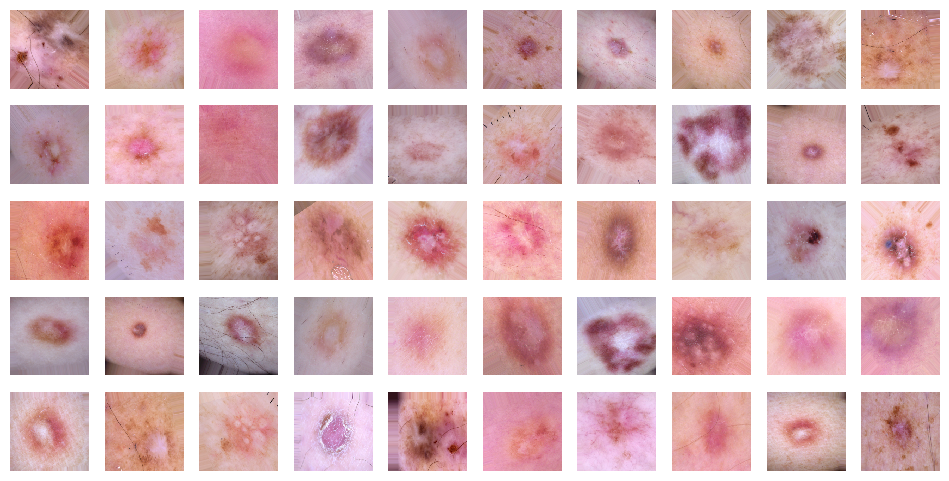

In [24]:
def plots(ims, figsize=(12,6), rows=5, interp=False, titles=None):
    if type(ims[0]) is np.ndarray:
        ims = np.array(ims).astype(np.uint8)
        if (ims.shape[-1] != 3):
            ims = ims.transpose((0,2,3,1))
    f = plt.figure(figsize=figsize)
    cols = len(ims) // rows if len(ims) % 2 == 0 else len(ims) // rows + 1
    for i in range(len(ims)):
        sp = f.add_subplot(rows, cols, i+1)
        sp.axis('Off')
        if titles is not None:
            sp.set_title(titles[i], fontsize = 16)
        plt.imshow(ims[i], interpolation=None if interp else 'none')
        
plots(imgs, titles=None)

### Set Up the Generators

In [25]:
train_path = 'base_dir/train_dir'
valid_path = 'base_dir/val_dir'

num_train_samples = len(df_train)
num_val_samples = len(df_val)
train_batch_size = 10
val_batch_size = 10
image_size = 224

train_steps = np.ceil(num_train_samples / train_batch_size)
val_steps = np.ceil(num_val_samples / val_batch_size)

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range = 40,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_batches = train_datagen.flow_from_directory(train_path,
                                                  target_size=(image_size, image_size),
                                                  batch_size=train_batch_size)

valid_batches = test_datagen.flow_from_directory(valid_path,
                                                 target_size=(image_size, image_size),
                                                 batch_size=val_batch_size)

test_batches = test_datagen.flow_from_directory(valid_path,
                                                target_size=(image_size, image_size),
                                                batch_size=1,
                                                shuffle=False)

Found 38569 images belonging to 7 classes.
Found 938 images belonging to 7 classes.
Found 938 images belonging to 7 classes.


### Modify MobileNet Model

In [27]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization

base_model = MobileNet(include_top=False, input_shape=(224, 224, 3), weights='imagenet')

for layer in base_model.layers[:-50]:
    layer.trainable = False
for layer in base_model.layers[-50:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
output = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 112, 112, 32)     128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 112, 112, 32)     288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 112, 112, 32)     128       
 ation)                                                      

In [28]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 112, 112, 32)     128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 112, 112, 32)     288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 112, 112, 32)     128       
 ation)                                                      

In [29]:
type(model.layers)

list

In [30]:
len(model.layers)

92

In [31]:
x = model.layers[-6].output
x = Dropout(0.25)(x)
predictions = Dense(7, activation='softmax')(x)

model = Model(inputs=model.input, outputs=predictions)

In [32]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 112, 112, 32)     128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 112, 112, 32)     288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 112, 112, 32)     128       
 ation)                                                    

In [33]:
for layer in model.layers[:-23]:
    layer.trainable = False

### Train the Model

In [34]:
from tensorflow.keras.metrics import categorical_accuracy, top_k_categorical_accuracy

def top_3_accuracy(y_true, y_pred):
    return top_k_categorical_accuracy(y_true, y_pred, k=3)

def top_2_accuracy(y_true, y_pred):
    return top_k_categorical_accuracy(y_true, y_pred, k=2)

In [35]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import TopKCategoricalAccuracy

model.compile(
    optimizer = Adam(learning_rate = 1e-5),
    loss = 'categorical_crossentropy',
    metrics = [
        'categorical_accuracy',
        TopKCategoricalAccuracy(k = 3, name = 'val_top_3_accuracy')
    ]
)

In [36]:
print(valid_batches.class_indices)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [38]:
from sklearn.utils import class_weight
import numpy as np

y_train = train_batches.classes

class_weights_array = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(y_train),
    y = y_train
)
class_weights = dict(enumerate(class_weights_array))

In [39]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

checkpoint = ModelCheckpoint(
    filepath = "model.h5",
    monitor = 'val_categorical_accuracy',
    save_best_only=True,
    mode = 'max',
    verbose = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor = 'val_categorical_accuracy',
    factor = 0.5,
    patience = 2,
    min_lr = 1e-5,
    verbose = 1,
    mode = 'max'
)

early_stop = EarlyStopping(
    monitor = 'val_categorical_accuracy',
    patience = 5,
    restore_best_weights = True,
    verbose = 1
)

callbacks_list = [checkpoint, reduce_lr, early_stop]

history = model.fit(
    train_batches,
    steps_per_epoch = train_steps,
    validation_data = valid_batches,
    validation_steps = val_steps,
    class_weight = class_weights,
    epochs = 50,
    verbose = 1,
    callbacks=callbacks_list
)

Epoch 1/50
908/908 [==============================] - ETA: 0s - loss: 1.7160 - categorical_accuracy: 0.3693 - val_top_3_accuracy: 0.7085
Epoch 1: val_categorical_accuracy improved from -inf to 0.81663, saving model to model.h5
908/908 [==============================] - 81s 85ms/step - loss: 1.7160 - categorical_accuracy: 0.3693 - val_top_3_accuracy: 0.7085 - val_loss: 0.6184 - val_categorical_accuracy: 0.8166 - val_val_top_3_accuracy: 0.9350 - lr: 1.0000e-05
Epoch 2/50
908/908 [==============================] - ETA: 0s - loss: 1.2828 - categorical_accuracy: 0.5249 - val_top_3_accuracy: 0.8404
Epoch 2: val_categorical_accuracy improved from 0.81663 to 0.82303, saving model to model.h5
908/908 [==============================] - 79s 86ms/step - loss: 1.2828 - categorical_accuracy: 0.5249 - val_top_3_accuracy: 0.8404 - val_loss: 0.5616 - val_categorical_accuracy: 0.8230 - val_val_top_3_accuracy: 0.9446 - lr: 1.0000e-05
Epoch 3/50
908/908 [==============================] - ETA: 0s - loss: 1

### Evaluate the model using the val set

In [40]:
model.metrics_names

['loss', 'categorical_accuracy', 'val_top_3_accuracy']

In [41]:
val_loss, val_cat_acc, val_top_3_acc = model.evaluate(
    test_batches,
    steps=len(df_val)
)

print('val_loss:', val_loss)
print('val_cat_acc:', val_cat_acc)
print('val_top_3_acc:', val_top_3_acc)

938/938 [==============================] - 6s 6ms/step - loss: 0.3505 - categorical_accuracy: 0.8998 - val_top_3_accuracy: 0.9861
val_loss: 0.35047587752342224
val_cat_acc: 0.8997867703437805
val_top_3_acc: 0.9861407279968262


In [42]:
model.load_weights('model.h5')

val_loss, val_cat_acc, val_top_3_acc = model.evaluate(
    test_batches,
    steps = len(df_val),
    verbose = 1
)

print('val_loss:', val_loss)
print('val_cat_acc:', val_cat_acc)
print('val_top_3_acc:', val_top_3_acc)

938/938 [==============================] - 6s 6ms/step - loss: 0.3505 - categorical_accuracy: 0.8998 - val_top_3_accuracy: 0.9861
val_loss: 0.35047587752342224
val_cat_acc: 0.8997867703437805
val_top_3_acc: 0.9861407279968262


In [43]:
print(history.history.keys())

dict_keys(['loss', 'categorical_accuracy', 'val_top_3_accuracy', 'val_loss', 'val_categorical_accuracy', 'val_val_top_3_accuracy', 'lr'])


### Plot the Training Curves

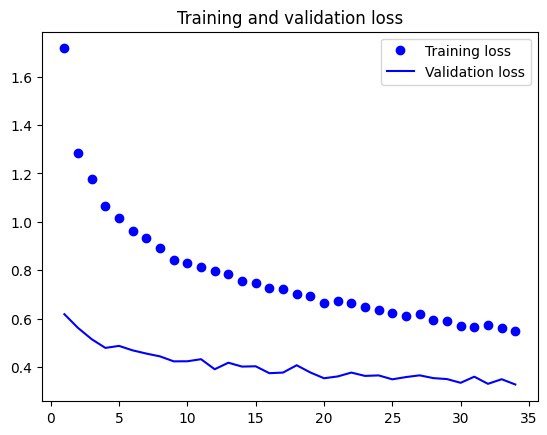

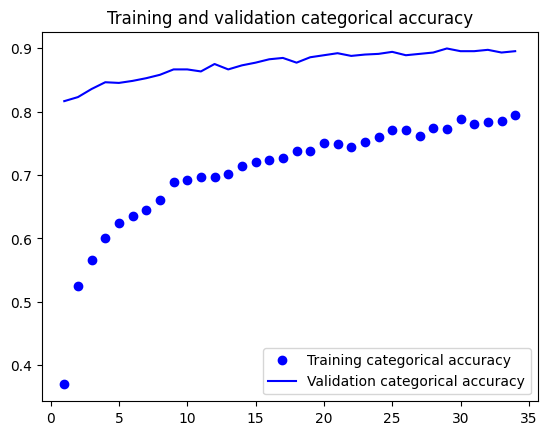

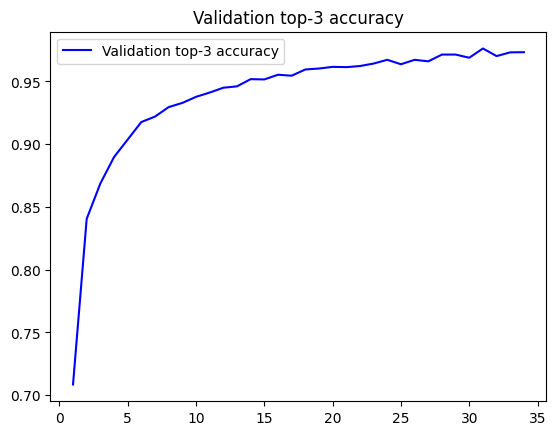

In [44]:
import matplotlib.pyplot as plt

acc = history.history['categorical_accuracy']
val_acc = history.history['val_categorical_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
val_top3_acc = history.history['val_top_3_accuracy']

epochs = range(1, len(acc) + 1)

# Loss
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.figure()

# Accuracy
plt.plot(epochs, acc, 'bo', label='Training categorical accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation categorical accuracy')
plt.title('Training and validation categorical accuracy')
plt.legend()
plt.figure()

# top-3 Accuracy (Validation only)
plt.plot(epochs, val_top3_acc, 'b', label='Validation top-3 accuracy')
plt.title('Validation top-3 accuracy')
plt.legend()

plt.show()

### Create a Confusion Matrix

In [45]:
test_labels = test_batches.classes

In [46]:
test_batches.class_indices

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}

In [47]:
predictions = model.predict_generator(test_batches, steps = len(df_val), verbose=1)

C:\ProgramData\miniconda3\envs\skin\lib\site-packages\ipykernel_launcher.py:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  """Entry point for launching an IPython kernel.


938/938 [==============================] - 5s 5ms/step


In [48]:
predictions.shape

(938, 7)

In [49]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

In [50]:
test_labels.shape

(938,)

In [51]:
cm = confusion_matrix(test_labels, predictions.argmax(axis=1))

In [52]:
test_batches.class_indices

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}

Confusion matrix, without normalization
[[  8   2  10   0   2   4   0]
 [  0  24   4   0   1   1   0]
 [  1   1  42   0   6  25   0]
 [  0   0   0   1   0   5   0]
 [  1   1   5   1  16  15   0]
 [  0   1   5   0   2 743   0]
 [  0   0   0   0   0   1  10]]


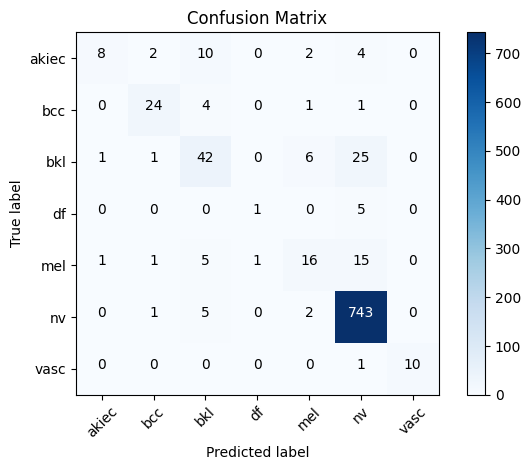

In [53]:
cm_plot_labels = ['akiec', 'bcc', 'bkl', 'df', 'mel','nv', 'vasc']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix')

In [54]:
y_pred = np.argmax(predictions, axis=1)
y_true = test_batches.classes

In [55]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=cm_plot_labels)
print(report)

              precision    recall  f1-score   support

       akiec       0.80      0.31      0.44        26
         bcc       0.83      0.80      0.81        30
         bkl       0.64      0.56      0.60        75
          df       0.50      0.17      0.25         6
         mel       0.59      0.41      0.48        39
          nv       0.94      0.99      0.96       751
        vasc       1.00      0.91      0.95        11

    accuracy                           0.90       938
   macro avg       0.76      0.59      0.64       938
weighted avg       0.89      0.90      0.89       938



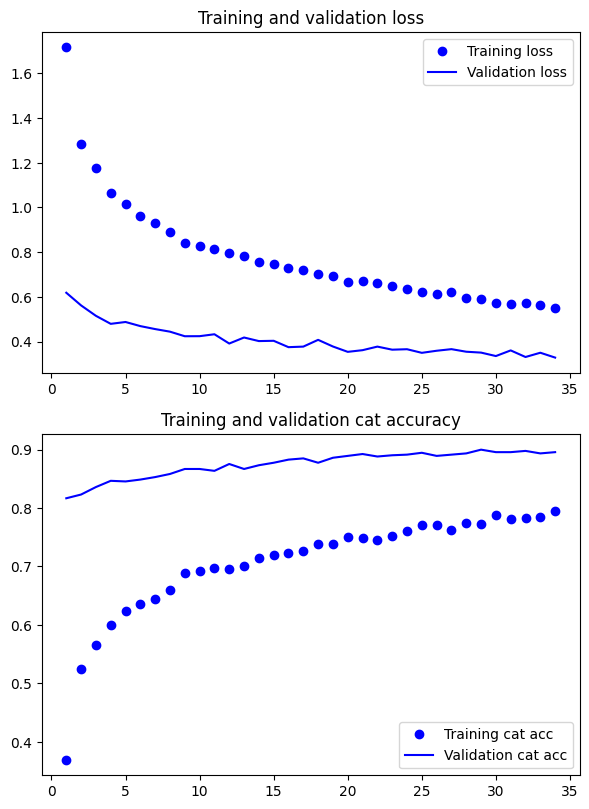

In [56]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize = (6, 16))

# 1. Loss
plt.subplot(4, 1, 1)
plt.plot(epochs, history.history['loss'], 'bo', label='Training loss')
plt.plot(epochs, history.history['val_loss'], 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

# 2. Categorical Accuracy
plt.subplot(4, 1, 2)
plt.plot(epochs, history.history['categorical_accuracy'], 'bo', label='Training cat acc')
plt.plot(epochs, history.history['val_categorical_accuracy'], 'b', label='Validation cat acc')
plt.title('Training and validation cat accuracy')
plt.legend()

# 3. Top-2 Accuracy
if 'top_2_accuracy' in history.history:
    plt.subplot(4, 1, 3)
    plt.plot(epochs, history.history['top_2_accuracy'], 'bo', label='Training top2 acc')
    plt.plot(epochs, history.history['val_top_2_accuracy'], 'b', label='Validation top2 acc')
    plt.title('Training and validation top2 accuracy')
    plt.legend()

# 4. Top-3 Accuracy
if 'top_3_accuracy' in history.history:
    plt.subplot(4, 1, 4)
    plt.plot(epochs, history.history['top_3_accuracy'], 'bo', label='Training top3 acc')
    plt.plot(epochs, history.history['val_top_3_accuracy'], 'b', label='Validation top3 acc')
    plt.title('Training and validation top3 accuracy')
    plt.legend()

plt.tight_layout()
plt.show()

In [57]:
shutil.rmtree('base_dir')

In [58]:
model.save('skin_lesion_model.h5')